# EfficientMath-AI: Post-Training Pipeline - GGUF Quantization + Gradio Deployment

- Loading the base Llama-3.1-8B model
- Loading the fine-tuned LoRA adapters
- Converting to GGUF (4-bit quantization)
- Building the Gradio interface (basic + advanced with CSS)
- Pushing the app to Hugging Face Spaces

In [ ]:
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps xformers trl peft accelerate bitsandbytes gradio

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-2nxkt6hl/unsloth_b8c339aa928a4b54a841bbbb10154e9f
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-2nxkt6hl/unsloth_b8c339aa928a4b54a841bbbb10154e9f
  Resolved https://github.com/unslothai/unsloth.git to commit fca83182afa44ab69bf79e65078f2dc4456cc8de
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.6/401.6 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 128.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 22.4 MB/s eta 0:00:0

In [ ]:
!pip install modelscope
import os
os.environ['UNSLOTH_USE_MODELSCOPE'] = '1'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 103.3 MB/s eta 0:00:00


# LOAD MODEL AND BUILD GRADIO UI

In [ ]:
import traceback
import torch
import gradio as gr
from google.colab import drive
from google.colab import userdata
from unsloth import FastLanguageModel
from transformers import TextIteratorStreamer  # NEW: For streaming text
from threading import Thread                   # NEW: For running generation in background

# 1. Connect to Drive & Get Token
print("Connecting to Google Drive...")
drive.mount('/content/drive')
hf_token = userdata.get('HF_TOKEN')

# 2. Define Path
adapter_path = "/content/drive/MyDrive/fine_tuned_gsm8k_adapters/files"

# 3. Load Model and Tokenizer
print("Loading the model and adapters...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = adapter_path,
    max_seq_length = 2048,
    dtype = None,
    load_in_4bit = True,
    token = hf_token
)

FastLanguageModel.for_inference(model)
print("Model loaded successfully!")

# 4. Define the streaming prediction function
def solve_math_problem(question):
    try:
        prompt = f"Below is a math word problem. Solve it step by step and provide the final answer.\n\n### Problem:\n{question}\n\n### Solution:\n"

        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

        # Setup the streamer to output words one-by-one
        # skip_prompt=True ensures it doesn't print your prompt instructions to the screen
        streamer = TextIteratorStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)

        # Package generation arguments into a dictionary
        generation_kwargs = dict(
            **inputs,
            streamer=streamer, # Inject the streamer here
            max_new_tokens=256,
            temperature=0.2,
            top_p=0.9,
            do_sample=True,
            use_cache=False,
            pad_token_id=tokenizer.eos_token_id
        )

        # Start generation in a separate background thread
        thread = Thread(target=model.generate, kwargs=generation_kwargs)
        thread.start()

        # Yield text to Gradio as it is generated to create the typewriter effect
        generated_text = ""
        for new_text in streamer:
            generated_text += new_text
            yield generated_text

    except Exception as e:
        yield f"CRASH REPORT:\n{str(e)}\n\nCheck Colab for full details."

# 5. Build a custom Pro UI using Gradio Blocks
# Inject custom CSS for the gradient background and modern styling
custom_css = """
.gradio-container {
    background: linear-gradient(135deg, #0f2027, #203a43, #2c5364) !important;
}
.markdown-text h1, .markdown-text p {
    color: white !important;
}
"""

with gr.Blocks(theme=gr.themes.Monochrome(), css=custom_css) as app:
    gr.Markdown("<h1 style='text-align: center; margin-top: 20px;'>EfficientMath-AI</h1>")
    gr.Markdown("<p style='text-align: center;'>This is a custom fine-tuned Llama 3.1 8B model, trained to solve grade school math word problems.</p>")

    with gr.Row():
        with gr.Column(scale=1):
            user_input = gr.Textbox(
                lines=5,
                placeholder="Enter a math word problem here...",
                label="Question"
            )
            with gr.Row():
                clear_btn = gr.ClearButton([user_input])
                submit_btn = gr.Button("Submit", variant="primary")

        with gr.Column(scale=1):
            # max_lines=50 allows the box to expand dynamically down the screen
            model_output = gr.Textbox(
                label="Model Solution",
                lines=5,
                max_lines=50,
                interactive=False
            )

    # Link the submit button to the function
    submit_btn.click(
        fn=solve_math_problem,
        inputs=user_input,
        outputs=model_output
    )

app.launch(share=True)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Connecting to Google Drive...
Mounted at /content/drive
Loading the model and adapters...
==((====))==  Unsloth 2026.3.10: Fast Llama patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/235 [00:00<?, ?B/s]

Unsloth: Will load /content/drive/MyDrive/fine_tuned_gsm8k_adapters/files as a legacy tokenizer.
Unsloth 2026.3.10 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


Model loaded successfully!


/tmp/ipykernel_1180/2497636930.py:78: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Monochrome(), css=custom_css) as app:
/tmp/ipykernel_1180/2497636930.py:78: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Monochrome(), css=custom_css) as app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6309be03338a7c84d3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# CONVERT TO GGUF AND UPLOAD TO HFSPACES

In [ ]:
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')
# Compress and Push Directly to space
print("Converting to GGUF and pushing to Hugging Face...")

model.push_to_hub_gguf(
    "iamabhayaditya/EfficientMath-AI", # My exact Hugging Face Space repository
    tokenizer,
    quantization_method = "q4_k_m",    # The 4-bit compression for free-tier CPUs
    token = hf_token
)

print("SUCCESS! Your GGUF model is now live in your Space.")

Converting to GGUF and pushing to Hugging Face...
Unsloth: Converting model to GGUF format...
Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/947 [00:00<?, ?B/s]

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Checking cache directory for required files...
Cache check failed: model-00001-of-00004.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


...

Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['/tmp/unsloth_gguf_59ph0yhh_gguf/Meta-Llama-3.1-8B.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['/tmp/unsloth_gguf_59ph0yhh_gguf/Meta-Llama-3.1-8B.Q4_K_M.gguf']
Unsloth: No Ollama template mapping found for model 'unsloth/Meta-Llama-3.1-8B'. Skipping Ollama Modelfile
Unsloth: example usage for text only LLMs: /root/.unsloth/llama.cpp/llama-cli --model /tmp/unsloth_gguf_59ph0yhh_gguf/Meta-Llama-3.1-8B.Q4_K_M.gguf -p "why is the sky blue?"
Unsloth: Uploading GGUF to Huggingface Hub...
Uploading Meta-Llama-3.1-8B.Q4_K_M.gguf...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...-Llama-3.1-8B.Q4_K_M.gguf:   0%|          | 23.9MB / 4.92GB            

Uploading config.json...
Unsloth: Successfully uploaded GGUF to https://huggingface.co/iamabhayaditya/EfficientMath-AI
Unsloth: Cleaning up temporary files...
SUCCESS! Your GGUF model is now live in your Space.


# PERFORMANCE METRICS

1. Generating Training Loss Curve...
2. Running Deep Evaluation on Test Set (This takes a few minutes)...


  0%|          | 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/te

3. Generating Perplexity & Generation Graphs...

✅ SUCCESS! High-resolution 'research_graphs.png' saved to your Colab files.


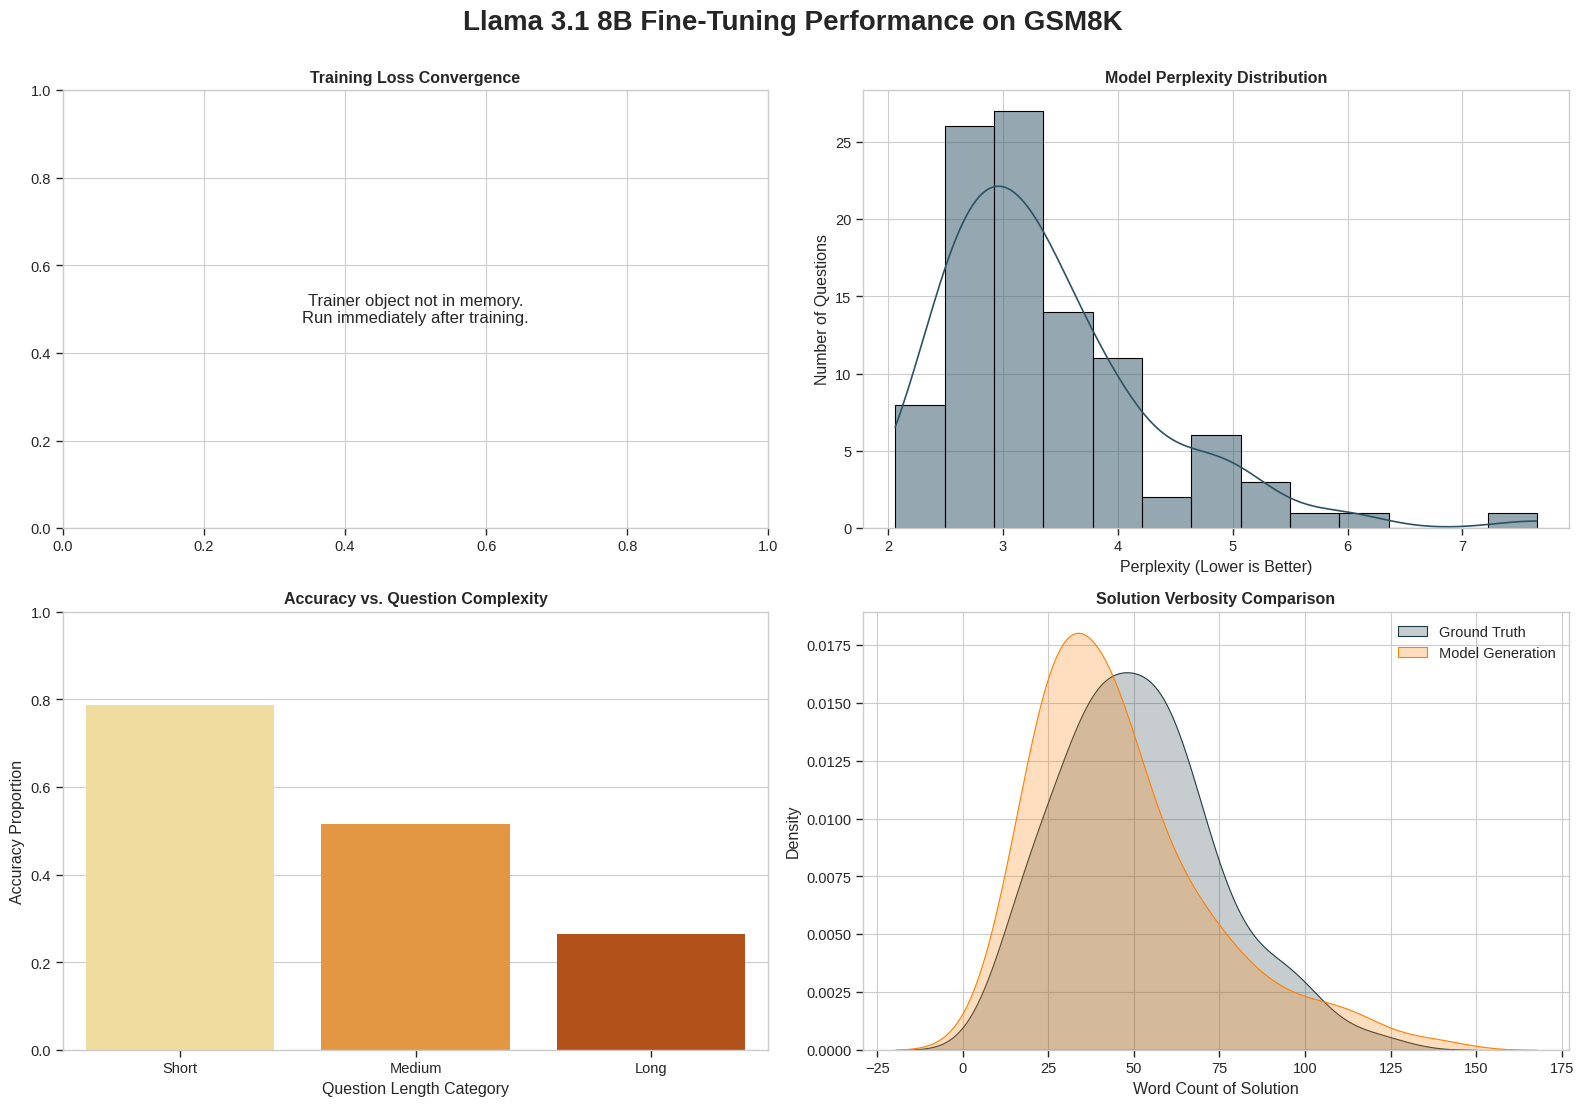

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import math
import re
from datasets import load_dataset

# 1. Setup Publication-Style Graphics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Llama 3.1 8B Fine-Tuning Performance on GSM8K', fontsize=20, fontweight='bold', y=0.95)

# 2. Extract Training Loss (If trainer is still in memory)
print("1. Generating Training Loss Curve...")
try:
    steps = [x['step'] for x in trainer.state.log_history if 'loss' in x]
    losses = [x['loss'] for x in trainer.state.log_history if 'loss' in x]

    axs[0, 0].plot(steps, losses, color='#ff7f00', linewidth=2)
    axs[0, 0].set_title('Training Loss Convergence', fontweight='bold')
    axs[0, 0].set_xlabel('Training Steps')
    axs[0, 0].set_ylabel('Cross Entropy Loss')
except NameError:
    axs[0, 0].text(0.5, 0.5, 'Trainer object not in memory.\nRun immediately after training.',
                   ha='center', va='center', fontsize=12)
    axs[0, 0].set_title('Training Loss Convergence', fontweight='bold')

# 3. Deep Evaluation on Test Set (100 samples for statistical significance)
print("2. Running Deep Evaluation on Test Set (This takes a few minutes)...")
test_dataset = load_dataset("openai/gsm8k", "main", split="test")

def extract_number(text):
    pattern = r"####\s*(-?\d+\.?\d*)"
    match = re.search(pattern, text)
    return float(match.group(1)) if match else None

results = []
sample_size = 100

# Switch to inference mode for speed
from unsloth import FastLanguageModel
FastLanguageModel.for_inference(model)

for i in tqdm(range(sample_size)):
    question = test_dataset[i]['question']
    true_answer_text = test_dataset[i]['answer']
    true_num = extract_number(true_answer_text)

    # Format Prompt
    prompt = f"Below is a math word problem. Solve it step by step and provide the final answer.\n\n### Problem:\n{question}\n\n### Solution:\n"
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    # A. Calculate Perplexity (Model's confidence/fluency)
    with torch.no_grad():
        loss_outputs = model(**inputs, labels=inputs["input_ids"])
        perplexity = math.exp(loss_outputs.loss.item())

    # B. Generate Answer for Accuracy & Length
    # THE FIX: Changed use_cache=True to use_cache=False
    generate_outputs = model.generate(**inputs, max_new_tokens=256, use_cache=False, pad_token_id=tokenizer.eos_token_id)
    model_output = tokenizer.decode(generate_outputs[0], skip_special_tokens=True)

    model_num = extract_number(model_output)
    is_correct = 0
    if model_num is not None and true_num is not None:
        if abs(model_num - true_num) < 1e-6:
            is_correct = 1

    # Save metrics
    results.append({
        'Question Length (Words)': len(question.split()),
        'Perplexity': perplexity,
        'Is Correct': is_correct,
        'True Solution Length': len(true_answer_text.split()),
        'Model Solution Length': len(model_output.split("### Solution:\n")[-1].split())
    })

df = pd.DataFrame(results)

# 4. Plot Perplexity Distribution
print("3. Generating Perplexity & Generation Graphs...")
sns.histplot(data=df, x='Perplexity', kde=True, ax=axs[0, 1], color='#2c5364')
axs[0, 1].set_title('Model Perplexity Distribution', fontweight='bold')
axs[0, 1].set_xlabel('Perplexity (Lower is Better)')
axs[0, 1].set_ylabel('Number of Questions')

# 5. Plot Accuracy vs Complexity
# Bin the question lengths into categories (Short, Medium, Long)
df['Complexity'] = pd.qcut(df['Question Length (Words)'], q=3, labels=['Short', 'Medium', 'Long'])
sns.barplot(data=df, x='Complexity', y='Is Correct', ax=axs[1, 0], palette='YlOrBr', errorbar=None)
axs[1, 0].set_title('Accuracy vs. Question Complexity', fontweight='bold')
axs[1, 0].set_xlabel('Question Length Category')
axs[1, 0].set_ylabel('Accuracy Proportion')
axs[1, 0].set_ylim(0, 1.0)

# 6. Plot Solution Length Comparison
sns.kdeplot(data=df['True Solution Length'], label='Ground Truth', ax=axs[1, 1], fill=True, color='#203a43')
sns.kdeplot(data=df['Model Solution Length'], label='Model Generation', ax=axs[1, 1], fill=True, color='#ff7f00')
axs[1, 1].set_title('Solution Verbosity Comparison', fontweight='bold')
axs[1, 1].set_xlabel('Word Count of Solution')
axs[1, 1].set_ylabel('Density')
axs[1, 1].legend()

# 7. Finalize and Save
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('research_graphs.png', dpi=300, bbox_inches='tight')
print("\n✅ SUCCESS! High-resolution 'research_graphs.png' saved to your Colab files.")
plt.show()